# Question Q.1
### Salary Data
#### Monthly salaries (in) of 200 employees follow a log-normal distribution with parameters:
- Mean of log(salary) = 10.5
- Standard deviation of log(salary) = 0.4

 **Find:**
1. Probability an employee earns more than ₹60,000.
2. Probability an employee earns between ₹30,000 and ₹50,000.
3. Plot the probability density curve.


Probability employee earns more than ₹60,000: 0.10469408193077034
Probability employee earns between ₹30,000 and ₹50,000: 0.4715230584638369


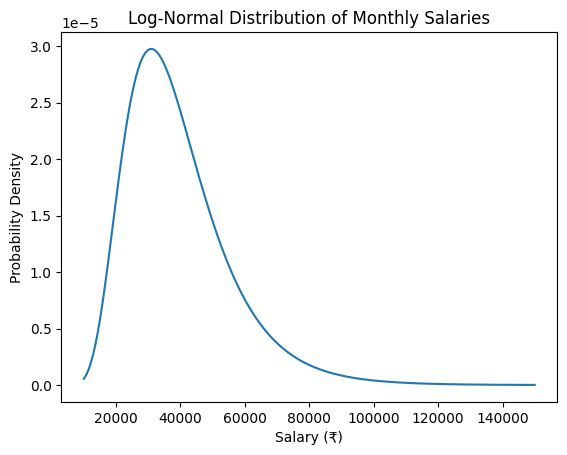

In [4]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.stats import lognorm

mu = 10.5
sigma = 0.4

distribution = lognorm(s=sigma,scale=np.exp(mu))

prob_above_60000 = 1 - distribution.cdf(60000)
prob_between_30k_50k = distribution.cdf(50000) - distribution.cdf(30000)

print("Probability employee earns more than ₹60,000:", prob_above_60000)
print("Probability employee earns between ₹30,000 and ₹50,000:", prob_between_30k_50k)

x = np.linspace(10000, 150000, 1000)
y = distribution.pdf(x)

plt.figure()
plt.plot(x, y)
plt.title("Log-Normal Distribution of Monthly Salaries")
plt.xlabel("Salary (₹)")
plt.ylabel("Probability Density")
plt.show()


# Q.2 Stock Prices

### A stock's daily returns are log-normally distributed.

- Mean of log(returns) = 0.02,
- Standard deviation = 0.1.

**Find:**
1. Probability that return > 10%.
2. Simulate 100 random values and visualize with histogram.


Probability that return > 10%: 1.0


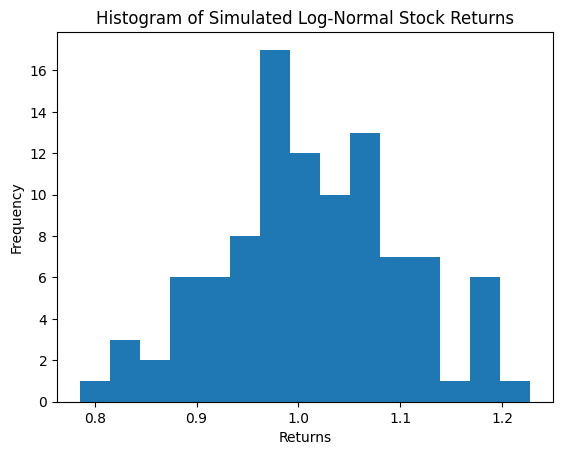

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

mu = 0.02      # Mean of log(returns)
sigma = 0.1    # Standard deviation

distribution = lognorm(s=sigma, scale=np.exp(mu))
 
prob_above_10 = 1 - distribution.cdf(0.10)
print("Probability that return > 10%:", prob_above_10)
 
np.random.seed(42)
simulated_returns = distribution.rvs(size=100)
 
plt.figure()
plt.hist(simulated_returns, bins=15)
plt.title("Histogram of Simulated Log-Normal Stock Returns")
plt.xlabel("Returns")
plt.ylabel("Frequency")
plt.show()

# Q.3 City Population Sizes
### City populations often follow a power-law. Suppose population sizes (x) follow:
- P(x) xx, a=2.5, x≥1000 \
**Find:** 
1. Probability that a city has more than 1,00,000 people.
2. Simulate 500 samples and plot histogram on log-log scale.



Probability that a city has more than 100000 people: 0.001


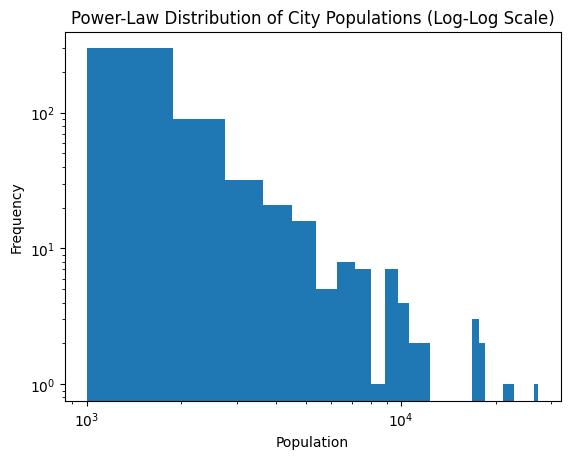

In [7]:
import numpy as np
import matplotlib.pyplot as plt

alpha = 2.5
xmin = 1000

# Probability that population > 100000
# For Pareto distribution: P(X > x) = (xmin / x)^(alpha - 1)
x_value = 100000
probability = (xmin / x_value) ** (alpha - 1)
print("Probability that a city has more than 100000 people:", probability)

# Simulate 500 samples
np.random.seed(42)
samples = (np.random.pareto(alpha - 1, 500) + 1) * xmin

# Plot histogram on log-log scale
plt.figure()
plt.hist(samples, bins=30)
plt.xscale('log')
plt.yscale('log')
plt.title("Power-Law Distribution of City Populations (Log-Log Scale)")
plt.xlabel("Population")
plt.ylabel("Frequency")
plt.show()


# Q.4 Social Network Connections
### Number of friends in a large social network follows a power-law with exponent α=3.
- Generate data for 2000 users.
- Plot degree distribution (number of friends).
- Show whether the curve fits power-law using log-log plot.



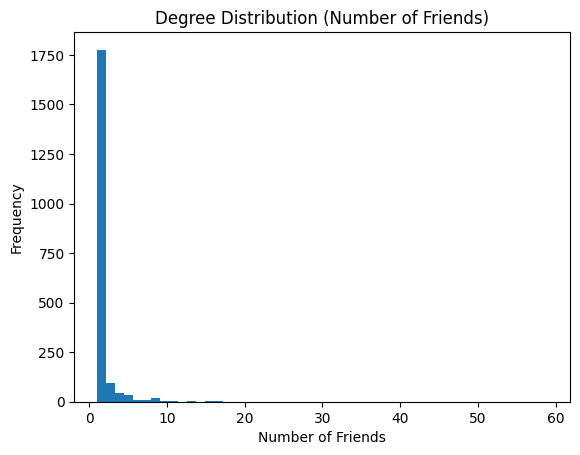

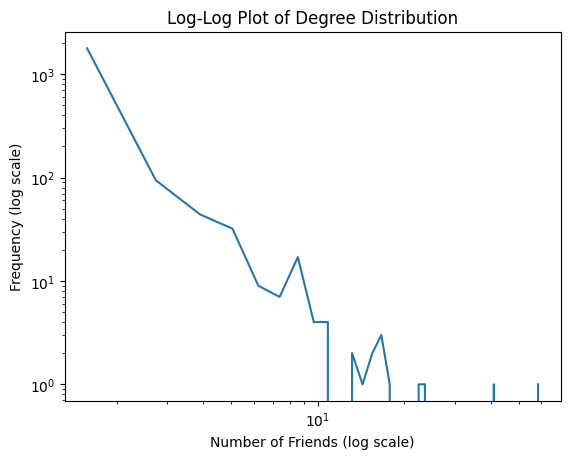

In [9]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt

# Given power-law exponent
alpha = 3
n_users = 2000

# For numpy pareto:
# If pareto parameter = a, then tail exponent = a + 1
# So to get exponent α = 3, we use a = 2
np.random.seed(42)
degrees = (np.random.pareto(alpha - 1, n_users) + 1) * 1

# Convert to integer number of friends
degrees = degrees.astype(int)

# Plot Degree Distribution (Normal Scale)
plt.figure()
plt.hist(degrees, bins=50)
plt.title("Degree Distribution (Number of Friends)")
plt.xlabel("Number of Friends")
plt.ylabel("Frequency")
plt.show()

# Log-Log Plot to Check Power-Law Fit
counts, bins = np.histogram(degrees, bins=50)
bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure()
plt.loglog(bin_centers, counts)
plt.title("Log-Log Plot of Degree Distribution")
plt.xlabel("Number of Friends (log scale)")
plt.ylabel("Frequency (log scale)")
plt.show()

# Q.5 Skewed Income Data
### Dataset of 1000 incomes is right-skewed.
- Apply Box-Cox transformation with 2 = 0.2.
- Compare histograms before & after transformation.
- Comment on normality improvement.

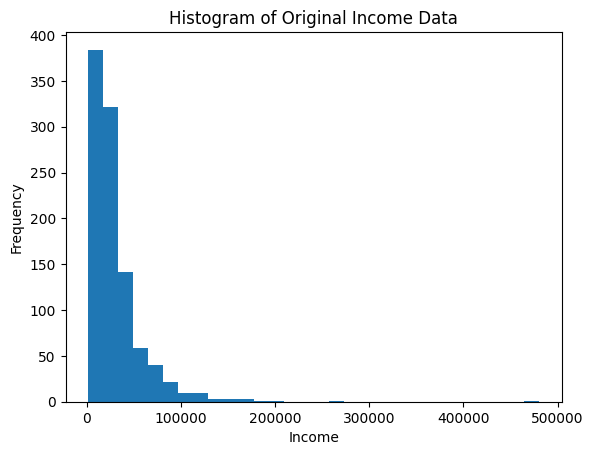

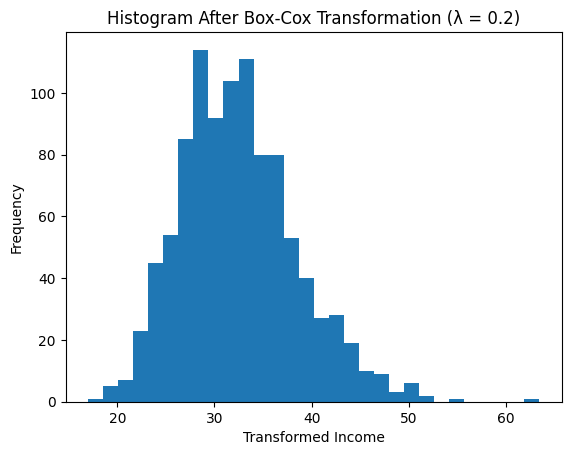

Comment: After Box-Cox transformation, the distribution appears more symmetric and closer to normal compared to the original right-skewed data.


In [12]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox

# Generate right-skewed income data (log-normal)
np.random.seed(42)
incomes = np.random.lognormal(mean=10, sigma=0.8, size=1000)

# Apply Box-Cox transformation with lambda = 0.2
lambda_value = 0.2
transformed_incomes = boxcox(incomes, lmbda=lambda_value)

#  Histogram Before Transformation
plt.figure()
plt.hist(incomes, bins=30)
plt.title("Histogram of Original Income Data")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

# Histogram After Box-Cox Transformation
plt.figure()
plt.hist(transformed_incomes, bins=30)
plt.title("Histogram After Box-Cox Transformation (λ = 0.2)")
plt.xlabel("Transformed Income")
plt.ylabel("Frequency")
plt.show()

print("Comment: After Box-Cox transformation, the distribution appears more symmetric and closer to normal compared to the original right-skewed data.")

# Q.6 Hospital Waiting Times
- Waiting times (positively skewed, min > 0) are recorded for 500 patients.
- Perform Box-Cox transformation (let software find optimal λ).
- Plot Q-Q plot before & after transformation.
- Explain effect of on distribution shape.


Optimal Lambda: -0.08103059815558639


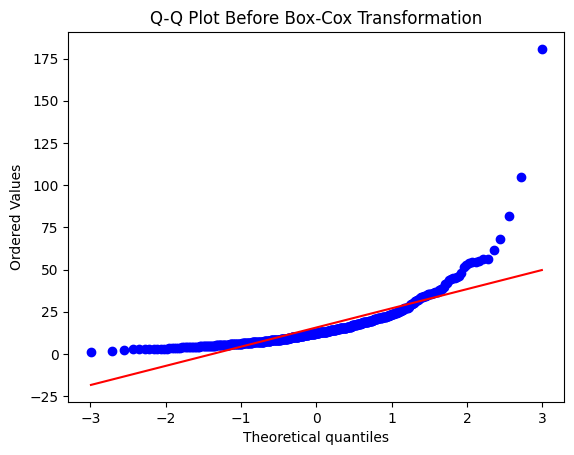

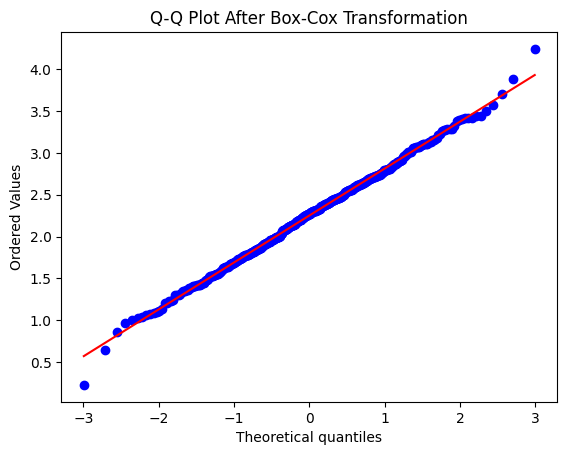

Effect: After Box-Cox transformation, the data aligns more closely to the straight line in the Q-Q plot, indicating reduced skewness and improved normality.


In [14]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox, probplot

# Generate positively skewed waiting time data (log-normal)
np.random.seed(42)
waiting_times = np.random.lognormal(mean=2.5, sigma=0.7, size=500)

# Apply Box-Cox transformation (optimal lambda chosen automatically)
transformed_data, optimal_lambda = boxcox(waiting_times)

print("Optimal Lambda:", optimal_lambda)

# 1️⃣ Q-Q Plot Before Transformation
plt.figure()
probplot(waiting_times, dist="norm", plot=plt)
plt.title("Q-Q Plot Before Box-Cox Transformation")
plt.show()

# 2️⃣ Q-Q Plot After Transformation
plt.figure()
probplot(transformed_data, dist="norm", plot=plt)
plt.title("Q-Q Plot After Box-Cox Transformation")
plt.show()

print("Effect: After Box-Cox transformation, the data aligns more closely to the straight line in the Q-Q plot, indicating reduced skewness and improved normality.")